In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

def plot_weekly(df):
    pd.options.plotting.backend='matplotlib'
    ppd = {'H':24, '15MIN':96}[df.index.freqstr.upper()] 
    ppw = ppd*7
    
    if df.index.weekday[0] != 0:
        df = df[ppd*(7-df.index.weekday[0]):]
    df = df[:ppw*(len(df)//ppw)]    

    pd.DataFrame(df.Load.values.reshape(-1,ppw).T).plot(alpha=0.05,legend=False)
    
def plot_daily(df):
    pd.options.plotting.backend='matplotlib'
    ppd = {'H':24, '15MIN':96}[df.index.freqstr.upper()] 
    pd.DataFrame(df[:ppd*(len(df)//ppd)].Load.values.reshape(-1,ppd).T).plot(alpha=0.1,legend=False)

def calc_nmae(y, yhat):
    y_minmax_normalized = (y - y.min()) / (y.max() - y.min())
    yhat_minmax_normalized = (yhat - y.min()) / (y.max() - y.min())
    return round((y_minmax_normalized - yhat_minmax_normalized).abs().mean(),3)

def calc_skill(y, ybench, yhat):
    return 1 - calc_nmae(y, yhat) / calc_nmae(y, ybench)

In [31]:
filepath = 'all_JPL_v5.csv'
df = pd.read_csv(filepath,index_col=0,comment='#',parse_dates=True)
df = df.resample('1h').mean()
df.loc['2019-7-8','Load'] = df.loc['2019-7-1','Load'].values
df.loc['2019-7-9','Persist1Workday'] = df.loc['2019-7-8','Load'].values
df

,Load,Persist1Workday
Datetime,,
2018-10-09 00:00:00,0.000000,0.000000
2018-10-09 01:00:00,0.000000,0.000000
2018-10-09 02:00:00,0.000000,0.000000
2018-10-09 03:00:00,0.000000,0.000000
2018-10-09 04:00:00,0.000000,0.000000
...,...,...
2020-01-19 19:00:00,0.000000,15.624614
2020-01-19 20:00:00,2.550267,9.263555
2020-01-19 21:00:00,31.514454,0.284426


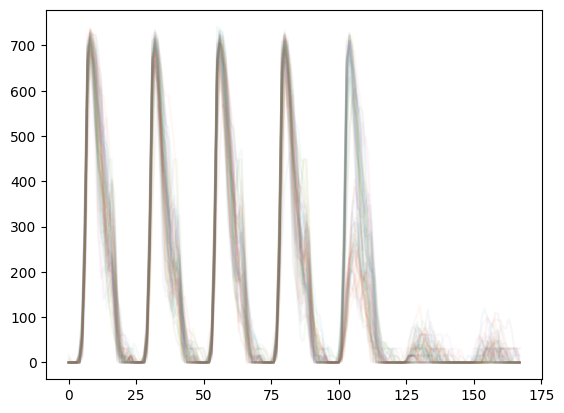

In [32]:
plot_weekly(df)

In [33]:
df4d = df[df.index.weekday<4]

<Axes: >

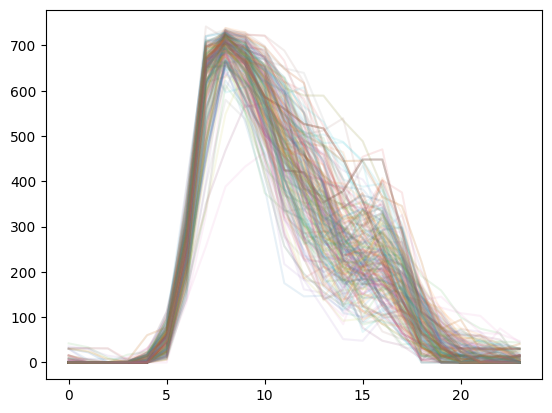

In [34]:
pd.DataFrame(df4d[:24*(len(df4d)//24)].Load.values.reshape(-1,24).T).plot(alpha=0.1,legend=False)

In [45]:
pd.DataFrame(df4d[:24*(len(df4d)//24)].Load.values.reshape(-1,24)).describe()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,...,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000,267.000000
mean,2.334232,1.126712,0.419027,0.413565,5.271684,47.979203,253.726653,622.398343,695.977700,657.788659,...,265.588943,241.606478,228.768994,169.100514,83.768391,37.289463,18.671800,12.460923,10.432229,6.359369
std,6.992157,5.175110,2.996155,1.709961,8.651639,23.546975,49.191642,81.337849,38.850725,45.387475,...,88.695509,86.239691,84.404830,67.927973,47.156464,30.742446,22.221171,17.385163,14.486114,10.182771
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,130.570075,255.916312,388.208998,432.402994,...,51.597038,47.963388,48.050756,34.023157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,28.856210,222.249530,597.097703,685.856946,633.863914,...,204.561107,186.932406,170.502064,116.379604,44.824551,13.881531,0.012434,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,47.678984,257.372612,649.524836,705.183650,667.236463,...,258.749445,228.842766,221.799016,164.735184,81.250663,30.709227,13.776621,2.299495,3.100000,0.000000
75%,0.053170,0.000000,0.000000,0.000000,10.392079,63.064527,286.507192,671.714303,717.469485,690.283688,...,314.386875,290.428152,281.953640,217.239386,117.077341,56.534587,30.730756,18.467632,15.732345,11.359670
max,42.182044,33.479968,31.111920,17.187279,60.172799,111.713121,387.503154,741.889148,738.653449,729.080851,...,539.108660,488.464996,470.572003,375.385955,221.843357,159.092682,108.913820,102.933681,75.206699,47.510889


<Axes: >

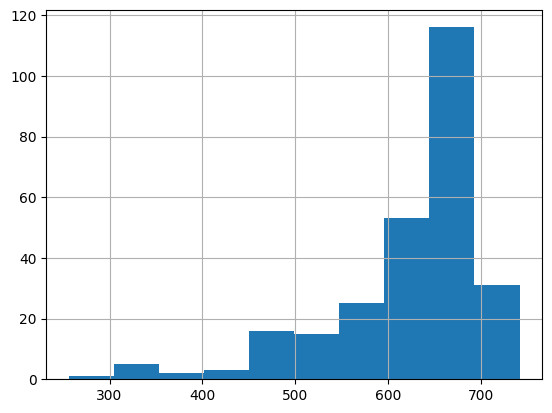

In [44]:
pd.DataFrame(df4d[:24*(len(df4d)//24)].Load.values.reshape(-1,24)).iloc[:,7].hist()